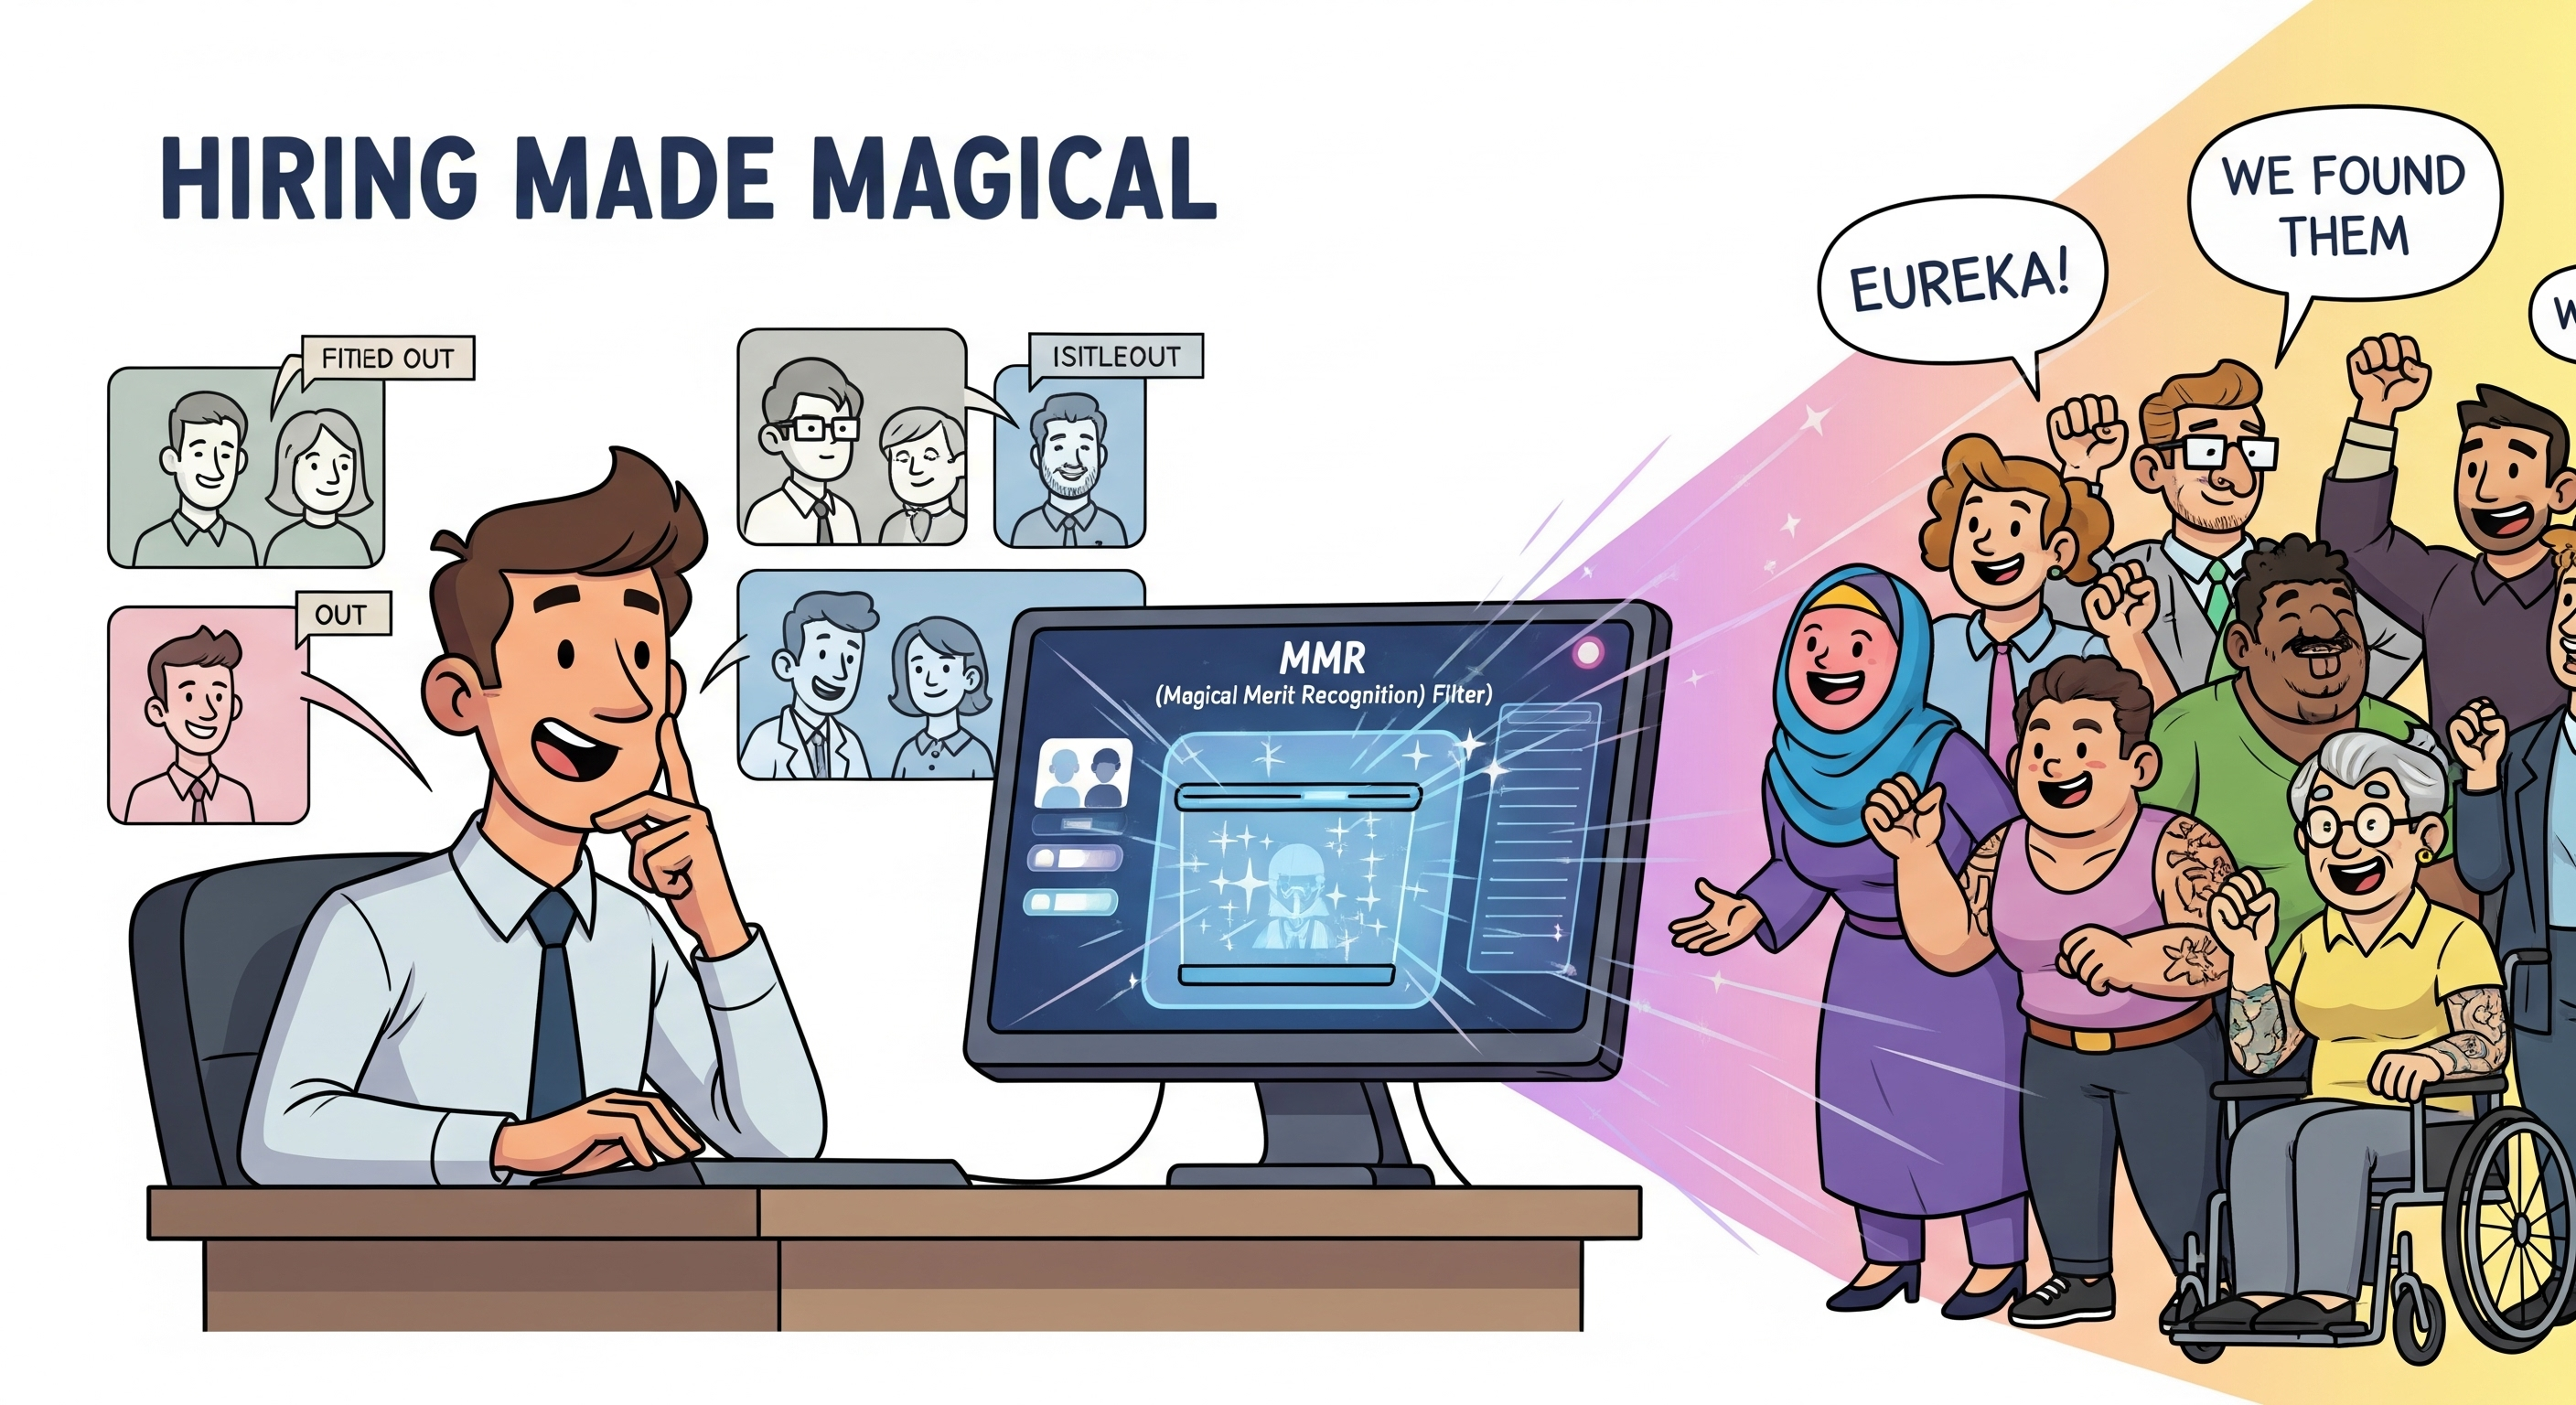

# Maximal Marginal Relevance (MMR) for Diverse Candidate Selection

This notebook demonstrates the implementation and usage of Maximal Marginal Relevance (MMR) for selecting a diverse subset of candidates based on their relevance to a query and their similarity to each other.

MMR is a technique used in information retrieval and natural language processing to improve the diversity of search results or selected items. It balances the relevance of an item to the query with its novelty compared to already selected items. This helps to avoid redundancy and provides a more comprehensive set of results.

In this notebook, we will:

1. Define a function to calculate embeddings for text using Azure OpenAI.
2. Implement the MMR algorithm.
3. Apply MMR to a set of candidate text snippets to select a diverse and relevant subset based on a query.

Let's get started!

In [ ]:
from openai import AzureOpenAI
from google.colab import userdata
client = AzureOpenAI(api_key=userdata.get('AZURE_API_KEY'), azure_endpoint=userdata.get('AZURE_BASE_URL'), api_version=userdata.get('AZURE_API_VERSION'))

def emd(text):
    return np.array(client.embeddings.create(input=[text], model=userdata.get('AZURE_EMBEDDING_NAME')).data[0].embedding)

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def maximal_marginal_relevance(query_vector, candidate_vectors, lambda_param=0.5, top_n=5):
    """
    Selects a subset of candidate vectors using Maximal Marginal Relevance (MMR).

    Parameters:
    - query_vector: numpy array of the query vector.
    - candidate_vectors: list of numpy arrays of candidate vectors.
    - lambda_param: float, balance between relevance and diversity (0 <= lambda_param <= 1).
    - top_n: int, number of vectors to select.

    Returns:
    - List of indices of selected candidate vectors.
    """
    selected_indices = []
    candidate_indices = list(range(len(candidate_vectors)))
    query_vector = query_vector.reshape(1, -1)

    # Compute similarity between the query and each candidate
    query_similarities = cosine_similarity(query_vector, candidate_vectors)[0]

    while len(selected_indices) < top_n and candidate_indices:
        mmr_scores = []
        for idx in candidate_indices:
            candidate_vector = candidate_vectors[idx].reshape(1, -1)
            # Compute diversity term
            if selected_indices:
                selected_similarities = cosine_similarity(candidate_vector, np.array([candidate_vectors[i] for i in selected_indices]))
                diversity_score = np.max(selected_similarities)
            else:
                diversity_score = 0
            # Compute MMR score
            mmr_score = lambda_param * query_similarities[idx] - (1 - lambda_param) * diversity_score
            mmr_scores.append((mmr_score, idx))

        # Select the candidate with the highest MMR score
        mmr_scores.sort(reverse=True, key=lambda x: x[0])
        best_score, best_idx = mmr_scores[0]
        selected_indices.append(best_idx)
        candidate_indices.remove(best_idx)

    return selected_indices

query_text = 'buscando candidato que sepa deep learning'
candidate_texts = [
    'yo soy cientifico de datos',
    'trabajo con scikit-learn y keras',
    'he procesado text, imagenes con vectores',
    'yo soy ingeniero agroindustrial',
    'yo conozco sobre cirugia dental',
    'yo trabajo en una industria de software',
    'yo soy ingeniera de calidad de software',
    'yo trabajo con python en páginas web con Angular',
]

query_vector = emd(query_text)
candidate_vectors = [emd(text) for text in candidate_texts]

selected_indices = maximal_marginal_relevance(query_vector, candidate_vectors, lambda_param=0.8, top_n=3)

print("Query:", query_text)
print("\nSelected Candidates:")
for index in selected_indices:
    print("-", candidate_texts[index])

Query: buscando candidato que sepa deep learning

Selected Candidates:
- trabajo con scikit-learn y keras
- yo soy cientifico de datos
- he procesado text, imagenes con vectores


In [ ]:
candidate_vectors

[array([ 2.34582033e-02, -9.29486100e-03,  1.31992344e-02, ...,
        -4.75982092e-02,  2.60575693e-02,  8.68064089e-05]),
 array([ 0.00258075,  0.02686841,  0.01878953, ..., -0.01636178,
         0.03015301, -0.02533832]),
 array([-0.00325251,  0.05680465, -0.0145134 , ..., -0.00581982,
        -0.02071196, -0.00165806]),
 array([-0.00278512, -0.00014799, -0.02925802, ..., -0.01578583,
         0.005275  ,  0.01376139]),
 array([-0.02201704,  0.01498856, -0.0094106 , ...,  0.018833  ,
         0.01350268,  0.00772424]),
 array([-0.00311871, -0.0009268 , -0.0151976 , ...,  0.00649776,
         0.0135596 ,  0.01000156]),
 array([ 0.02917621,  0.00770045, -0.02049935, ..., -0.01051357,
         0.00726238, -0.02313829]),
 array([-0.02917173, -0.00535492, -0.03489395, ..., -0.02464808,
         0.04086749,  0.00926961])]

## Another MMR Example: Book Recommendations

Let's explore another example of how MMR can be used, this time for recommending a diverse set of science fiction books based on a query.

In [ ]:
# New example case
query_text_2 = "recommend a good book about science fiction"
candidate_texts_2 = [
    "The Hitchhiker's Guide to the Galaxy is a comedy science fiction series.",
    "Dune is a science fiction novel by Frank Herbert.",
    "Foundation is a science fiction series by Isaac Asimov.",
    "Pride and Prejudice is a novel by Jane Austen.",
    "1984 is a dystopian social science fiction novel by George Orwell.",
    "To Kill a Mockingbird is a novel by Harper Lee.",
    "Brave New World is a dystopian novel by Aldous Huxley.",
]

query_vector_2 = emd(query_text_2)
candidate_vectors_2 = [emd(text) for text in candidate_texts_2]

selected_indices_2 = maximal_marginal_relevance(query_vector_2, candidate_vectors_2, lambda_param=0.7, top_n=4)

print("Query:", query_text_2)
print("\nSelected Candidates:")
for index in selected_indices_2:
    print("-", candidate_texts_2[index])

Query: recommend a good book about science fiction

Selected Candidates:
- Foundation is a science fiction series by Isaac Asimov.
- Dune is a science fiction novel by Frank Herbert.
- The Hitchhiker's Guide to the Galaxy is a comedy science fiction series.
- 1984 is a dystopian social science fiction novel by George Orwell.


Let's walk through this notebook on Maximal Marginal Relevance (MMR).

First, we have a markdown cell that introduces the concept of MMR and explains its purpose in selecting diverse candidates based on relevance and similarity. It also outlines the steps the notebook will cover.

Next, there's a code cell that sets up the Azure OpenAI client and defines a function `emd` to generate embeddings for text using the specified Azure OpenAI model.

Following that, we have a code cell that defines the `maximal_marginal_relevance` function. This function takes the query vector and candidate vectors, along with parameters for balancing relevance and diversity (`lambda_param`) and the desired number of results (`top_n`). It then iteratively selects candidates based on their MMR score, which considers both their similarity to the query and their dissimilarity to already selected candidates. This cell also includes the first example, applying MMR to a set of candidate texts related to a job query and printing the selected candidates.

Then, there is an empty code cell that was previously modified.

After that, a markdown cell introduces a second example, this time focusing on book recommendations using MMR.

Finally, there's a code cell that implements this second example. It defines a new query and a list of candidate book titles, generates their embeddings, applies the `maximal_marginal_relevance` function, and prints the selected book recommendations.

In summary, this notebook demonstrates how to use the MMR algorithm to select a diverse set of candidates, first with a job candidate example and then with a book recommendation example, using text embeddings generated by Azure OpenAI.